# Data Challenge 9 — Feature Engineering & Feature Selection

**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Engineer better predictors (one-hot/dummies, interactions, polynomials), avoid unnecessary complexity, and compare a **Base** vs **Engineered** model on the **same train–test split** using **MAE/RMSE**. Interpret coefficients in units and explain business value.



> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple*: light numeric coercion only for your chosen columns.

## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

**Docs (quick links):**
- One-hot encoding (pandas): https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html  
- OneHotEncoder (sklearn): https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html  
- Train/Test Split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- MAE / MSE / RMSE: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html  
- OLS (statsmodels): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html  
- OLS Results (coef/p/CIs/resid): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html

### Pseudocode Plan (Feature Engineering + Selection)
1) **Load CSV** → preview columns/shape.  
2) **Pick Y and initial Xs (2–3 numeric)** → keep it simple and decision-time-available.  
3) **Engineer features:**
   - **One-hot** a categorical with a dropped baseline (e.g., `payment_type` or `weekday/weekend`).  
   - **Interaction**: choose a hypothesis-driven pair (e.g., `trip_distance × is_weekend`).  
   - **Polynomial**: add one squared term for a plausible curve (e.g., `trip_distance²`).  
4) **Build Base vs Engineered design matrices** (add intercept).  
5) **Single train–test split** (80/20, fixed `random_state`) shared by both models.  
6) **Fit on TRAIN**, **predict on TEST** for both models; compute **MAE/RMSE** (units of Y).  
7) **Interpretation**: write unit-based coefficient sentences; note baseline category for dummies.  
8) **Light selection**: if Engineered model doesn’t beat Base on TEST (or adds complexity w/o value), prefer Base.  
9) **Diagnostics (quick)**: residuals vs fitted (train); note any cones (heteroskedasticity).  
10) **Stakeholder one-liner**: which model, why (TEST metrics in units), and what the added features *mean*.
markdown


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [231]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your **Dec 2023** taxi CSV.
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [232]:
df = pd.read_csv("../data/2023_Yellow_Taxi_Trip_Data_20251015.csv")
print(df.shape,'\n',df.columns)

/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_5075/432262165.py:1: DtypeWarning: Columns (4,10,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/2023_Yellow_Taxi_Trip_Data_20251015.csv")


(3310907, 19) 
 Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')


### Step 2 —  Pick Target **Y** and Predictors **Xs** (choose 2–3 numeric)

- **Avoid** using an X that directly defines Y (e.g., `total_amount` when Y = `fare_amount`).
- Coerce **only these columns** to numeric; drop NA rows.

In [233]:
# Coerce fare, distance, tolls, and tips to numeric safely
num_cols = ['fare_amount', 'trip_distance','tolls_amount','tip_amount']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
    
# Clean data some by removing values less than 0 and dropping NAN values
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)

len(df)

3310907

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3310907 entries, 0 to 3310906
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           object 
 17  congestion_surcharge   float64
 18  airport_fee            float64
dtypes: float64(11), int64(4), object(4)
memory usage: 479.9+ MB


In [235]:
# choosing values greater than 0 for fare_amount for only fares with money paid 
# & keeping tolls amount and tip amount greater than or equal to 0 to account for those who may not have paid
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0) & (df['tolls_amount'] >= 0) & (df['tip_amount'] >= 0)]

df['payment_type'] = df['payment_type'].replace({0:"Flex_Fare",1:'Credit_Card',2:'Cash',3:'No_Charge',4:'Dispute'})

# lost about 110000 records
print(len(df))


x = df[['tip_amount','tolls_amount','payment_type','trip_distance']]
y = df['fare_amount']


3200255


### Step 3 —  Engineer New Features (One-hot, Interaction, Polynomial)

Pick **one** categorical to one-hot (drop baseline). Options that usually exist:

- `payment_type` (codes): treat as categorical strings for clarity, then one-hot with drop_first=True, or  
- derive **weekday/weekend** from `tpep_pickup_datetime` if present.

Then add **one interaction** and **one squared term** guided by a business hypothesis.

In [236]:
# dummy variables create booleans for our different payment types
# dropped is cash (now we know intercept is cash + everything else)
dummies_pd = pd.get_dummies(x['payment_type'], drop_first=True, prefix='payment')
x = pd.concat([x, dummies_pd], axis=1)
print("--- Data with pd.get_dummies ---")
print(x.head(5))

--- Data with pd.get_dummies ---
   tip_amount  tolls_amount payment_type  trip_distance  payment_Credit_Card  \
0      3.0000        0.0000  Credit_Card         0.6900                 True   
1      0.0000        0.0000         Cash         1.1000                False   
3      0.0000        0.0000      Dispute         1.5700                False   
4      3.0000        0.0000  Credit_Card         3.0000                 True   
6      0.0000        0.0000      Dispute         1.2400                False   

   payment_Dispute  payment_Flex_Fare  payment_No_Charge  
0            False              False              False  
1            False              False              False  
3             True              False              False  
4            False              False              False  
6             True              False              False  


In [237]:
# interaction term
# hypothesis: our above average tippers have longer rides?

x['above_average_tip'] = x['tip_amount'] > x['tip_amount'].quantile(0.5)
x['tripdistance_x_aat'] = x['trip_distance'] * x['above_average_tip']

x

,tip_amount,tolls_amount,payment_type,trip_distance,payment_Credit_Card,payment_Dispute,payment_Flex_Fare,payment_No_Charge,above_average_tip,tripdistance_x_aat
0,3.0000,0.0000,Credit_Card,0.6900,True,False,False,False,True,0.6900
1,0.0000,0.0000,Cash,1.1000,False,False,False,False,False,0.0000
3,0.0000,0.0000,Dispute,1.5700,False,True,False,False,False,0.0000
4,3.0000,0.0000,Credit_Card,3.0000,True,False,False,False,True,3.0000
6,0.0000,0.0000,Dispute,1.2400,False,True,False,False,False,0.0000
...,...,...,...,...,...,...,...,...,...,...
3310901,0.0000,0.0000,Cash,0.7100,False,False,False,False,False,0.0000
3310902,2.3600,0.0000,Credit_Card,1.7000,True,False,False,False,False,0.0000
3310903,18.4600,6.9400,Credit_Card,21.6000,True,False,False,False,True,21.6000
3310905,17.5400,0.0000,Credit_Card,0.0100,True,False,False,False,True,0.0100


In [238]:
#squared trip distance for potential curve
x['trip_distancesquared'] = x['trip_distance'] ** 2

### Step 4 — Build **Base** and **Engineered** Design Matrices

- **Base** = intercept + base predictors (Xs you assigned in Step 2) 
- **Engineered** = intercept + base predictors + engineered columns (dummies + interaction + polynomial)


In [239]:
base = sm.add_constant(x[['tip_amount','tolls_amount','trip_distance']])

engineered = sm.add_constant(x[['tip_amount','tolls_amount','trip_distance','payment_Credit_Card','payment_Dispute','payment_No_Charge','payment_Flex_Fare','tripdistance_x_aat','trip_distancesquared']])

engineered[['payment_Credit_Card','payment_Dispute','payment_Flex_Fare','payment_No_Charge']] = engineered[['payment_Credit_Card','payment_Dispute','payment_Flex_Fare','payment_No_Charge']].astype(int)


### Step 5 — Single Train–Test Split (Shared by Both Models)

Use one split so Base and Engineered are comparable.

In [240]:
np.random.seed(9001)

basex_train, basex_test, basey_train, basey_test = train_test_split(base, y, test_size=0.2, random_state=9001)

engineeredx_train, engineeredx_test, engineeredy_train, engineeredy_test = train_test_split(engineered, y, test_size=0.2, random_state=9001)


### Step 6 — Fit on TRAIN, Predict on TEST, Compute **MAE/RMSE** (units of Y)

In [241]:
# BASE MODEL

basemodel = sm.OLS(basey_train, basex_train).fit()

# --- Evaluate the model on the unseen testing data ---
basepredictions = basemodel.predict(basex_test)

basemae = mean_absolute_error(basey_test, basepredictions)
basermse = np.sqrt(mean_squared_error(basey_test, basepredictions))

print(f"\nMean Absolute Error (MAE) on Test Data: {basemae:.2f}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {basermse:.2f}")
print(f"\nInterpretation: Our model's predicting fare amounts on new data are off by an average of ${basemae*1000:,.2f}.")


Mean Absolute Error (MAE) on Test Data: 7.76
Root Mean Squared Error (RMSE) on Test Data: 12.69

Interpretation: Our model's predicting fare amounts on new data are off by an average of $7,760.98.


In [242]:
# ENGINEERED MODEL

engineermodel = sm.OLS(engineeredy_train, engineeredx_train).fit()
engineerpredictions = engineermodel.predict(engineeredx_test)

engineeredmae = mean_absolute_error(engineeredy_test, engineerpredictions)
engineeredrmse = np.sqrt(mean_squared_error(engineeredy_test, engineerpredictions))

print(f"\nMean Absolute Error (MAE) on Test Data: {engineeredmae:.2f}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {engineeredrmse:.2f}")
print(f"\nInterpretation: Our model's predicting fare amounts on new data are off by an average of ${engineeredmae:,.2f}.")



Mean Absolute Error (MAE) on Test Data: 7.17
Root Mean Squared Error (RMSE) on Test Data: 12.19

Interpretation: Our model's predicting fare amounts on new data are off by an average of $7.17.


In [243]:
basemodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                 9.133e+05
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:27:51   Log-Likelihood:            -1.0066e+07
No. Observations:             2560204   AIC:                         2.013e+07
Df Residuals:                 2560200   BIC:                         2.013e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            12.0231      0.010   1158.223      0.000      12.003      12.043
tip_amount        1.6031      0.002    743.089      0.000       1.599       1.607
tolls_amount      3.7538      0.004    952.532      0.000       3.746       3.762
trip_distance     0.0012   4.64e-05     25.224      0.000       0.001       0.001
==============================================================================
Omnibus:                  3462739.294   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      27022353652.443
Skew:                           6.542   Prob(JB):                         0.00
Kurtosis:                     506.133   Cond. No.                         226.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Step 7 — Interpret Key Coefficients (Plain Language)

Write **unit-based** interpretations for 2–3 impactful coefficients **in the Engineered model**, noting:
- The **baseline** category for dummies (the dropped category).
- **Interaction** meaning (change in slope under the condition).
- **Polynomial** meaning (curve: does effect rise then taper?).


*(Use this template; edit to your variables/units):*

- **Dummy (pay_…):** Compared to baseline cash payments, the expected fare amount is $9.90 lower on credit card payments, 25 cents higher on disputed payments, $1.61 lower on rides that weren't charged, and $1.36 lower  on flex fare rides when holding other features constant.  
- **Interaction (dist×weekend):** On above average tipped rides, each additional mile changes fare amounts by less than 1 cent than on below average tipped rides, holding other features constant.  
- **Polynomial (distance²):** The marginal effect of distance changes with distance; the negative/positive β on distance² indicates diminishing returns.

### Step 8 —  Quick Diagnostics (Train Residuals) — Engineered Model
- **Residuals vs Fitted:** random cloud ≈ good; cone/funnel suggests non-constant variance.  
- **Q–Q plot:** points roughly along diagonal (normality for inference).  
- **Durbin–Watson:** printed in `eng_model.summary()` (~2 suggests independence).

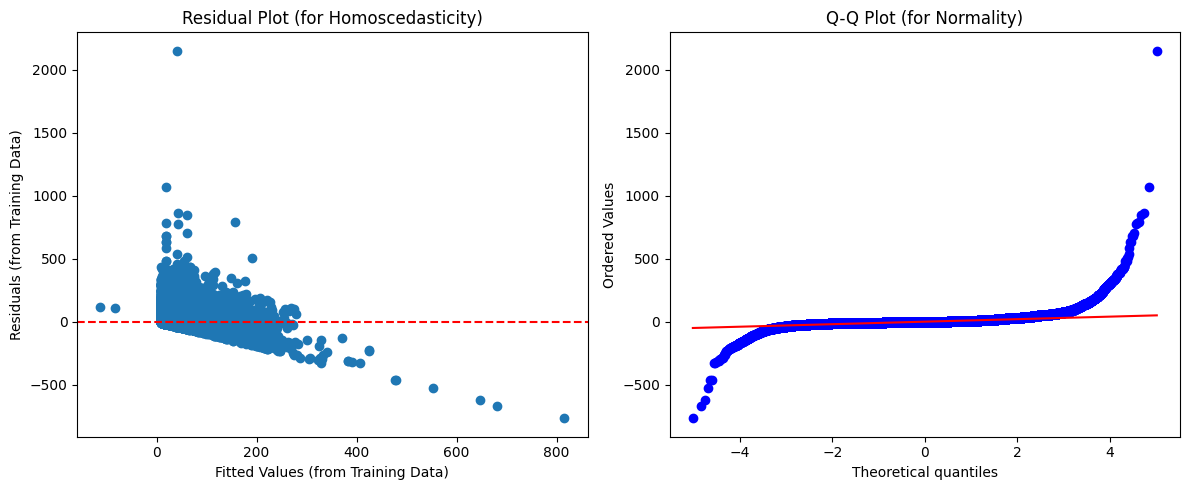

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                 3.572e+05
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:27:56   Log-Likelihood:            -9.9566e+06
No. Observations:             2560204   AIC:                         1.991e+07
Df Residuals:                 2560194   BIC:                         1.991e+07
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   18.2169 

In [244]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- Check assumptions using the training data model ---
# Residuals from the model trained on X_train, y_train
train_residuals = engineermodel.resid 

# 1. Plot for Homoscedasticity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(engineermodel.fittedvalues, train_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (for Homoscedasticity)')
plt.xlabel('Fitted Values (from Training Data)')
plt.ylabel('Residuals (from Training Data)')

# 2. Q-Q Plot for Normality
plt.subplot(1, 2, 2)
stats.probplot(train_residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (for Normality)')

plt.tight_layout()
plt.show()

# 3. Durbin-Watson statistic is in the summary output below
print(engineermodel.summary())

## We Share — Reflection & Wrap‑Up

**Notes on Feature Selection**
- If **Engineered** doesn’t beat **Base** on TEST (or gains are tiny), prefer **Base** for simplicity.  
- If two engineered features are redundant (e.g., highly correlated dummies), consider dropping one.  
- Keep features that improve TEST error **and** you can explain to a stakeholder.


Write **2 short paragraphs** and be specific:


1) **Which model would you deploy today—Base or Engineered—and why?**  
Use **TEST MAE/RMSE in units**, your coefficient interpretations (baseline/interaction/polynomial), and any residual observations.

Although our MAE and RMSE was better on our engineered model compared to the base model, I would choose the base model as it would be a lot simpler to explain. I think the best way to add any additional features is to focus on only some of the features I engineered instead of all. As when I was interpreting the model in common language, it was more difficult to explain all the base and new features, and maybe will be more confusing and less impactful to stakeholders.

2) **What engineered feature was most useful (or not)?**  
Explain the **business logic** behind it and whether it earned its place on the TEST set. If not, what would you try next (different interaction, different categorical, or simplifying features)?

The most useful was the one-hot encoding, as we were able to see the effect payment types had on the fare amount. It was interesting to see on the engineered model a decrease in our Y (fare amount) in the most used form of payment, credit cards. What I would try next is to avoid dropping our cash payments, as this could also be a main contributor to fare amounts, especially seeing our y-intercept increase drastically after the one-hot encoding.